In [53]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
%env XLA_PYTHON_CLIENT_MEM_FRACTION=.8

env: XLA_PYTHON_CLIENT_MEM_FRACTION=.8


In [55]:
import jax
jax.devices()

[CpuDevice(id=0)]

In [56]:
import sys
sys.path.append('/home/ninarell/OneDrive/WP_GAN/B_GEN/flow_diagrams/') 
import flow_diagrams

In [57]:
import jax
import time
import equinox as eqx
import numpy as np
import matplotlib.pyplot as plt
from jax import numpy as jnp
from IPython.display import clear_output
from jax import Array
# from openmm import unit
import optax
from flow_diagrams.utils.conditioning import convert_from_reduced_p, convert_from_reduced_t
from matplotlib import colors
from jax_md import space, partition
import pickle

In [58]:
from flow_diagrams.utils.train import log_weights_given_latent, normalize_weights, sampling_efficiency, effective_sample_size, delta_f_to_prior
from flow_diagrams.utils.visualization import radial_distribution_function
from flow_diagrams.utils.data import NumpyLoader, split_data
from flow_diagrams.utils.symmetry import *

from jax import numpy as jnp

#from flow_diagrams.energy.lennard_jones import fd_lennard_jones_neighbor_list
from jax_md.energy import stillinger_weber_neighbor_list

from flow_diagrams.models.coupling_flows import ConditionalCouplingFlowNPT

from flow_diagrams.utils.train import running_average
# from flow_diagrams.utils.lattice import volume_to_box
from flow_diagrams.utils.weights import get_weights, get_biases
from flow_diagrams.utils.jax import key_chain
from IPython.display import clear_output
from flow_diagrams.utils.conditioning import grid_conditional_variables
import time

In [59]:
chain = key_chain(1)

In [77]:
EPSILON_cal   = 6.189 #in units kcal/mol
EPSILON = EPSILON_cal / 0.239005736 #in units kJ/mol
SIGMA_ang = 2.3925 #in units Angstroms
Sigma_nm = SIGMA_ang * 1e-1 #in units nm
SIGMA = Sigma_nm #in units nm
a         = 1.80 #dimensionless
lam       = 23.15 #dimensionless
gamma     = 1.20 #dimensionless
A         = 7.049556277 #dimensionless
B         = 0.6022245584 #dimensionless
p         = 4. #dimensionless
q         = 0. #dimensionless
#theta_0   = np.radians(109.47)
NUM_PARTICLES = 60
NUM_SAMPLES = 20000
SPATIAL_DIMENSIONS = 3
kB = 0.00831446261815324 # in (unit.kilojoule_per_mole/unit.kelvin)
kB_cal = kB * 0.239005736
CUTOFF= a * SIGMA
print(kB_cal)
#CUTOFF= a * SIGMA
print(EPSILON, SIGMA)

0.001987204257496202
25.89477601491539 0.23925000000000002


In [61]:
# %%
def remove_disp_of_first_atom(displacements):
    # assert displacements.shape == (NUM_PARTICLES, SPATIAL_DIMENSIONS)

    disp_at_1 = displacements[0,:]

    return displacements - disp_at_1


def transform_abs_coords_to_rel_coords(absolute_coordinates: Array, side_length: Array):
    """Transforms relative coordinates inside the unit cube to absolute coordinates given a 3d box_vector."""
    assert absolute_coordinates.shape[-1] == SPATIAL_DIMENSIONS
    assert side_length.shape == (3,)
    return absolute_coordinates / side_length



def wrap_to_unit_cube(pos, lower, upper):
    width = upper - lower
    return jnp.mod(pos - lower, width) + lower

def wrap_to_box(pos, box):
    return pos % box

# %%
jax.config.update("jax_enable_x64", False)


In [ ]:
LOWER = 0.
UPPER = 1.
CUT_TYPE = 'switch'

Press_atm = 0.0 #in atm
Press_1e30_Pa_per_mol = 1.01325 * 6.022 * 1e-2 * Press_atm
PRIOR_PRESSURE = Press_1e30_Pa_per_mol # in units sigma_nm**3 / epsilon_kJ/mol = 1e3 Pa/mol
TEMP_PRIOR  = 270.
md_seed = 301098
TEMP_INT = int(TEMP_PRIOR)

#print(1/(kB/EPSILON))
#print(1/(SIGMA**3 / EPSILON))

#REDUCED_TEMP_PRIOR = TEMP_PRIOR * kB / EPSILON
#REDUCED_PRESS_PRIOR = PRIOR_PRESSURE * SIGMA**3 / EPSILON

REDUCED_TEMP_PRIOR = TEMP_PRIOR / convert_from_reduced_t(EPSILON, kB)
REDUCED_PRESS_PRIOR = PRIOR_PRESSURE / convert_from_reduced_p(EPSILON, SIGMA)

#[T]mW = 3114.4 K, and [p]mW = 31 400 bars.

#filename_prior = "mW_ex_data_T_270_P_1.0_N_60_Ns_20000_md_seed_301098.npz"
filename_prior = "2e4_2e7_sim_dump_T_270_P_1.0_N_60_Ns_20000_seed_63782_pbc_tonpz.npz"

data_prior = jnp.load(filename_prior)
positions_prior_abs = data_prior['pos'] * 1e-1 #in units nm
box_prior = data_prior['box'] * 1e-1 #in units nm
vols_prior = jnp.prod(box_prior, axis=-1)
BOX_EDGES = np.mean(box_prior, axis=0)

# fix first atom in origin and wrap to box
positions_prior = jax.vmap(wrap_to_box)(jax.vmap(remove_disp_of_first_atom)(positions_prior_abs),box_prior)
MEAN_CONFIG = np.mean(positions_prior,axis=0)

# scale to [0,1]
positions_prior= jax.vmap(transform_abs_coords_to_rel_coords)(positions_prior,box_prior)
positions_prior = wrap_to_unit_cube(positions_prior,LOWER,UPPER)    

scale_prior = box_prior[:,0] / BOX_EDGES[0]
energies_prior = data_prior['ene'] / 0.239005736 #in units kJ/mol

assert np.logical_and(1. >= UPPER, positions_prior >= LOWER).all()
assert np.allclose(positions_prior[:,0,:],0,atol=1e-7)

n_samples = positions_prior.shape[0] 


128


In [108]:
print(REDUCED_PRESS_PRIOR, REDUCED_TEMP_PRIOR) #REDUCED_TEMP_PRIOR
print(PRIOR_PRESSURE, TEMP_PRIOR) #REDUCED_TEMP_PRIOR

0.0 0.08669335102988764
0.0 270.0


In [ ]:
INTERVAL_FRACTION_P = 0.08 #0.05 -> 0.2 -> 0.8 -> 0.1


p_max = INTERVAL_FRACTION_P    * convert_from_reduced_p(EPSILON, SIGMA)
p_min = - INTERVAL_FRACTION_P  * convert_from_reduced_p(EPSILON, SIGMA) 

t_max = 350.
t_min = 220.

grid_length = 80
conditioning_states= grid_conditional_variables(t_min,t_max,p_min, p_max, grid_length,grid_length)

print(p_max,p_min, REDUCED_PRESS_PRIOR)
print(t_max,t_min, REDUCED_PRESS_PRIOR)


151.26773583189444 -151.26773583189444 0.0
350.0 220.0 0.0


In [114]:
BATCH_SIZE = 128
train_fraction = 1.
# Store all displacements relative to first one (which stays at its equilibrium position)
dataset_prior_train, dataset_prior_test = split_data(train_fraction, positions_prior,
                        energies_prior,
                       scale_prior)
dataloader_train = NumpyLoader(dataset_prior_train,BATCH_SIZE,False)



In [115]:
dtype = np.float32


format = partition.Dense #OrderedSparse

displacement_frac, shift_frac = space.periodic_general(BOX_EDGES, fractional_coordinates=False)

neighbor_fn, energy_fn = stillinger_weber_neighbor_list(
    displacement=displacement_frac,
    box_size=BOX_EDGES,
    sigma=SIGMA,
    A = A,
    B = B,
    lam = lam,
    gamma = gamma,
    epsilon= EPSILON,
    cutoff = CUTOFF,
    dr_threshold= 0.01, #LARGE threshold to match lammps calculations
    fractional_coordinates=False,
    format = format
    ) 

NEIGHBOR_LIST = neighbor_fn.allocate(MEAN_CONFIG)

In [116]:
def compute_sw_energy(pos_rel: jnp.ndarray, scale):
    box= scale * BOX_EDGES
    nbrs = NEIGHBOR_LIST.update(pos_rel * box)
    sw_energy = energy_fn(pos_rel * box, nbrs, box=box)

    return sw_energy

In [117]:
flow = ConditionalCouplingFlowNPT(n_layers=1,
                            num_hidden=2,
                            dim_hidden=32,
                            num_hidden_shape=4,
                            dim_hidden_shape=16,
                            dim_embedd =32,
                            lower=0,
                            upper=1,
                            n_bins=16,
                            n_heads=1,
                            t_max=t_max,
                            p_max=p_max,
                            use_layer_norm=True,
                            n_blocks=1,
                            use_circular_shift=True,
                            n_freqs=8,
                            init_identity=True,
                            n_particles=NUM_PARTICLES ,
                            key= next(chain))

params, static = eqx.partition(flow, eqx.is_array)
param_count = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"{param_count:_}")

156_587


In [118]:
n_batches = len(dataloader_train)


initial_lr = 1e-5
optim = optax.adam(initial_lr)
optim = optax.chain(optax.clip_by_global_norm(1e4), optim)


params, static = eqx.partition(flow, eqx.is_array)
opt_state = optim.init(params)
key = key_chain(1)

# %%
@eqx.filter_jit
def evaluate_flow(flow,pos,scale,press,temp):
    return flow(pos=pos,scale=scale,press=press,temp=temp)


def calculate_new_pos_and_scale_batch(batch_pos, batch_scale, p_rand, t_rand, flow):

    def single_flow(pos, scale, press, temp):
        return flow.forward(pos, scale, press=press, temp=temp)[0:3]

    return jax.vmap(single_flow)(batch_pos, batch_scale, p_rand, t_rand)


In [119]:

# === 1. Carica lo stato del training (pickle) ===
with open("training_state.pkl", "rb") as f:
    training_state = pickle.load(f)

print("Training state keys:", training_state.keys())  # se è un dizionario

# === 2. Carica il modello Equinox ===
flow = eqx.tree_deserialise_leaves("flow.eqx", like=flow)

# === 3. Carica lo stato dell’ottimizzatore ===
opt_state = eqx.tree_deserialise_leaves("opt_state.eqx", like=None)

print("Flow model loaded:", type(flow))
print("Optimizer state loaded:", type(opt_state))

Training state keys: dict_keys(['optimized_state'])
Flow model loaded: <class 'flow_diagrams.models.coupling_flows.ConditionalCouplingFlowNPT'>
Optimizer state loaded: <class 'NoneType'>


In [120]:
def log_weights_and_conf_given_latent(
    pos_prior,
    scale_prior,
    prior_energy,
    temp_and_pressure_target,
    temp_and_pressure_flow,
    reference_box,
    n_particles,
    pressure_prior,
    temp_prior,
    target_energy_fn,
    flow,
):
    """Computes the weights for one sample.

    params:
    --------------------------
    logw: unnormalized weights"""

    prior_vol = jnp.prod(scale_prior * reference_box)

    target_temp = temp_and_pressure_target[0]
    target_press = temp_and_pressure_target[1]

    flow_temp = temp_and_pressure_flow[0]
    flow_press = temp_and_pressure_flow[1]

    new_pos, new_scale, ldj = flow.forward(
        pos=pos_prior, scale=scale_prior, temp=flow_temp, press=flow_press
    )
    new_box = new_scale * reference_box
    new_vol = jnp.prod(new_box)

    target_energy = target_energy_fn(new_pos, new_scale)

    ldj_initial = n_particles * (jnp.log(1.0 / prior_vol))
    ldj_final = n_particles * (jnp.log(new_vol))

    ldj += ldj_final + ldj_initial
    logw = (
        -(target_energy + new_vol * target_press) / (kB * target_temp)
        + ldj
        + (prior_energy + prior_vol * pressure_prior) / (kB * temp_prior)
    )

    return logw, new_pos, new_scale, target_energy


In [121]:
results = {}  # qui salviamo i dati prima di scrivere il file

for (target_temp, target_press) in conditioning_states:
    all_energies = []
    all_boxes = []
    all_weights = []

    # Genera batch e calcola energie/volumi
    for ibatch, (batch_pos, batch_ene, batch_scale) in enumerate(dataloader_train):
        
        # temperatura e pressione fisse per il batch
        t_batch = jnp.full((batch_pos.shape[0],), target_temp) 
        p_batch = jnp.full((batch_pos.shape[0],), target_press)
        
        # genera nuove configurazioni dal flow
        logw , new_pos, new_scale, energy_batch = jax.vmap(lambda pos, ene, scal: log_weights_and_conf_given_latent(
            pos_prior=pos,
            prior_energy=ene,
            scale_prior=scal,
            flow=flow,
            temp_and_pressure_target=jnp.array([target_temp, target_press]),
            temp_and_pressure_flow=jnp.array([target_temp, target_press]),
            n_particles=NUM_PARTICLES,
            pressure_prior=PRIOR_PRESSURE,
            temp_prior=TEMP_PRIOR,
            reference_box=BOX_EDGES,
            target_energy_fn=compute_sw_energy,
        ))(batch_pos, batch_ene, batch_scale)
               
        box_batch = jax.device_get(new_scale)[:, jnp.newaxis] * BOX_EDGES

        all_energies.append(energy_batch)
        all_boxes.append(box_batch)
        all_weights.append(logw)
    
    # concatena
    new_energies = np.concatenate(all_energies)[:n_samples]
    new_boxes = np.concatenate(all_boxes)[:n_samples]
    new_vol = np.prod(new_boxes, axis=1)
    new_weights = np.concatenate(all_weights)[:n_samples]
    
    # salva in results con chiavi uniche
    key_prefix = f"{target_temp}_{target_press}"
    results[f"{key_prefix}_energy"] = new_energies
    results[f"{key_prefix}_volume"] = new_vol
    results[f"{key_prefix}_weight"] = new_weights


# === Salva in un unico file npz ===
np.savez("generated_data.npz", **results)
print("Salvato in generated_data.npz")

Salvato in generated_data.npz


In [122]:
efficiencies = jnp.empty((0,))

for (target_temp, target_press) in conditioning_states:
    key_prefix = f"{target_temp}_{target_press}"
    efficiency = sampling_efficiency(results[f"{key_prefix}_weight"])
    efficiencies = jnp.concatenate((efficiencies, jnp.array([ efficiency])))

In [123]:
contour = plt.tricontourf(
    conditioning_states[:, 0]/ convert_from_reduced_t(EPSILON, kB),
    conditioning_states[:, 1] / convert_from_reduced_p(EPSILON, SIGMA),
    efficiencies * 100,
    norm=colors.LogNorm(),
    levels=np.geomspace(1e-0, 100, 11),
)
plt.colorbar(contour, ticks=np.geomspace(1e-0, 100, 11))
plt.scatter(
    conditioning_states[:, 0] / convert_from_reduced_t(EPSILON, kB),
    conditioning_states[:, 1] / convert_from_reduced_p(EPSILON, SIGMA),
    alpha=0.2,
)
plt.plot(REDUCED_TEMP_PRIOR, REDUCED_PRESS_PRIOR, "x", color="blue")

plt.set_cmap("Reds")
plt.xlabel("T*")
plt.title("ESS [%]")
plt.ylabel("P*")
#plt.axis([0.3,0.4,1.8,2.5])
plt.tight_layout()

# ---- Save figure ----
plt.savefig("ess_contour.png", dpi=300, bbox_inches="tight")

# ---- Close to free memory ----
plt.close()

In [124]:
test_temp_list = jnp.array([230., 240., 250., 260., 270., 280., 290., 300., 310., 320., 330., 340.])

weight_array = jnp.zeros((len(test_temp_list), n_samples))
position_array = jnp.zeros((len(test_temp_list), n_samples, NUM_PARTICLES, SPATIAL_DIMENSIONS))
scale_array = jnp.zeros((len(test_temp_list), n_samples))
energy_array = jnp.zeros((len(test_temp_list), n_samples))

for i in range(len(test_temp_list)):
    # Prepare accumulators for this temperature
    test_temp = test_temp_list[i]
    
    w_norm = [] 
    pos    = [] 
    scale  = [] 
    energy = [] 

        # Genera batch e calcola energie/volumi
    for ibatch, (batch_pos, batch_ene, batch_scale) in enumerate(dataloader_train):

        w_x_L_E_batch = jax.vmap(lambda pos, ene, scal: log_weights_and_conf_given_latent(
            pos_prior=pos,
            prior_energy=ene,
            scale_prior=scal,
            flow=flow,
            temp_and_pressure_target=jnp.array([test_temp, PRIOR_PRESSURE]),
            temp_and_pressure_flow=jnp.array([test_temp, PRIOR_PRESSURE]),
            n_particles=NUM_PARTICLES,
            pressure_prior=PRIOR_PRESSURE,
            temp_prior=TEMP_PRIOR,
            reference_box=BOX_EDGES,
            target_energy_fn=compute_sw_energy,
        ))(batch_pos, batch_ene, batch_scale)

        w_norm_batch = normalize_weights(w_x_L_E_batch[0])


        w_norm.append(w_norm_batch) 
        pos.append(w_x_L_E_batch[1]) 
        scale.append(w_x_L_E_batch[2]) 
        energy.append(w_x_L_E_batch[3]) 
    
    print("Calculated for temp = ", test_temp)
    
    weight_array = weight_array.at[i].set(np.array(w_norm)[0])
    position_array = position_array.at[i].set(np.array(pos)[0])
    scale_array = scale_array.at[i].set(np.array(scale)[0])
    energy_array = energy_array.at[i].set(np.array(energy)[0])

print(weight_array.shape)



Calculated for temp =  230.0
Calculated for temp =  240.0
Calculated for temp =  250.0
Calculated for temp =  260.0
Calculated for temp =  270.0
Calculated for temp =  280.0
Calculated for temp =  290.0
Calculated for temp =  300.0
Calculated for temp =  310.0
Calculated for temp =  320.0
Calculated for temp =  330.0
Calculated for temp =  340.0
(12, 128)


In [125]:
def weighted_var(list, avg, log_weights):
    return jnp.sum(jnp.exp(log_weights)*((list - avg)**2))/jnp.sum(jnp.exp(log_weights))

In [126]:
vc_md = np.load("MD_VC_DATA_"+str(NUM_PARTICLES)+".npz")["v_c_list"]
K_md = np.load("MD_K_DATA_"+str(NUM_PARTICLES)+".npz")["K_list"]

v_c_list = np.zeros(len(test_temp_list))
K_list = np.zeros(len(test_temp_list))
ess_list = np.zeros(len(test_temp_list))
for k in range(len(test_temp_list)):
    w_norm = weight_array[k]
    scales = scale_array[k]
    v_red = (scales * BOX_EDGES[0]/SIGMA)**3
    v_red_avg = np.sum(jnp.exp(w_norm)*v_red)/jnp.sum(jnp.exp(w_norm))
    v_red_var = weighted_var(v_red, v_red_avg, w_norm)
    #print(v_red_var)
    v_c = v_red / NUM_PARTICLES
    v_c_list[k] = np.sum(jnp.exp(w_norm)*v_c)/jnp.sum(jnp.exp(w_norm))
    K_list[k] = (v_red_var/v_red_avg)/(test_temp_list[k]/convert_from_reduced_t(EPSILON, kB))
    ess_list[k] = effective_sample_size(w_norm)/ len(w_norm)

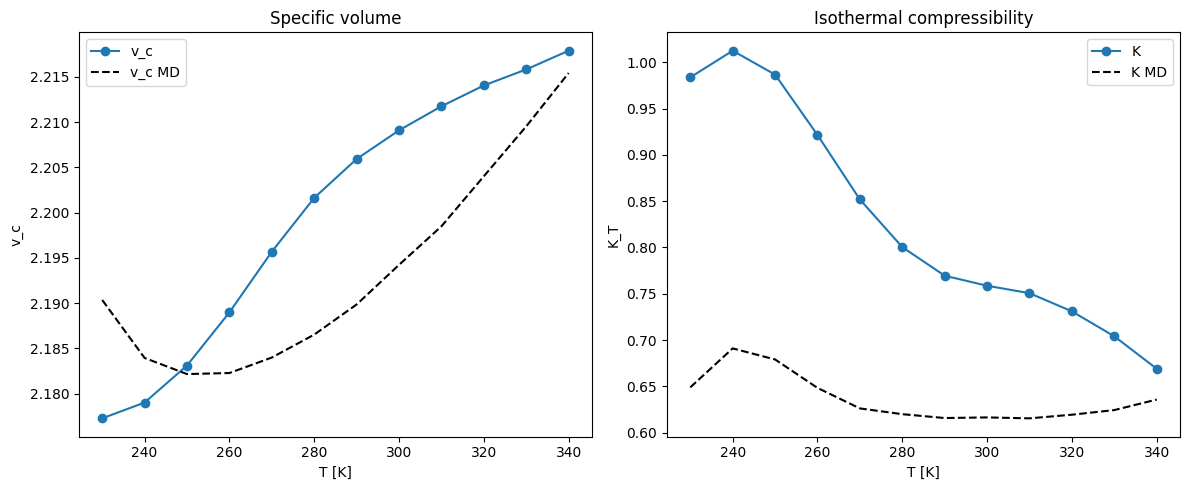

In [127]:
import pandas as pd
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(test_temp_list, v_c_list, label='v_c', linestyle='-', marker='o')
ax[0].plot(test_temp_list, vc_md, label='v_c MD', color='black', linestyle='--')
ax[0].set_xlabel('T [K]')
ax[0].set_ylabel('v_c')
ax[0].legend()
ax[0].set_title('Specific volume')

ax[1].plot(test_temp_list, K_list, label='K', marker='o')
ax[1].plot(test_temp_list, K_md, label='K MD', color='black', linestyle='--')
ax[1].set_xlabel('T [K]')
ax[1].set_ylabel('K_T')
ax[1].legend()
ax[1].set_title('Isothermal compressibility')


plt.tight_layout()

# Save the figure
plt.savefig("thermo_properties.png", dpi=300, bbox_inches='tight')


# ---- Save curve data ----
data = pd.DataFrame({
    "T [K]": test_temp_list,
    "v_c": v_c_list,
    "v_c MD": vc_md,
    "K": K_list,
    "K MD": K_md
})

data.to_csv("thermo_properties_data.csv", index=False)